# PharmaInsight AI — Forecastability & Demand Analysis

## Objective

This notebook investigates the historical demand patterns of pharmaceutical product
categories in the PharmaInsight AI dataset.

The analysis focuses on:

- Demand distributions
- Descriptive statistics
- Demand variability
- Zero-demand behavior
- Temporal trends
- Seasonality
- Autocorrelation
- Cross-category relationships
- Outliers and anomalies
- Forecastability characteristics

The results will be used to guide the design and selection of the downstream
demand forecasting models.

### Dataset

The analysis uses the daily pharmaceutical sales dataset containing eight
pharmaceutical product categories:

- M01AB
- M01AE
- N02BA
- N02BE
- N05B
- N05C
- R03
- R06

The project also contains hourly, weekly, and monthly datasets. The daily dataset
is used as the primary analytical resolution in this notebook because it provides
a sufficiently long historical sequence for statistical and forecasting analysis.

PharmaInsight AI environment loaded successfully.
Project root: /workspaces/PharmaInsight-AI
Python: /workspaces/PharmaInsight-AI/.venv/bin/python
Rows:        2,106
Columns:     13
Start date:  2014-01-02 00:00:00
End date:    2019-10-08 00:00:00
<class 'pandas.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   datum         2106 non-null   datetime64[us]
 1   M01AB         2106 non-null   float64       
 2   M01AE         2106 non-null   float64       
 3   N02BA         2106 non-null   float64       
 4   N02BE         2106 non-null   float64       
 5   N05B          2106 non-null   float64       
 6   N05C          2106 non-null   float64       
 7   R03           2106 non-null   float64       
 8   R06           2106 non-null   float64       
 9   Year          2106 non-null   int64         
 10  Month         2106 non-null   int64         
 11  H

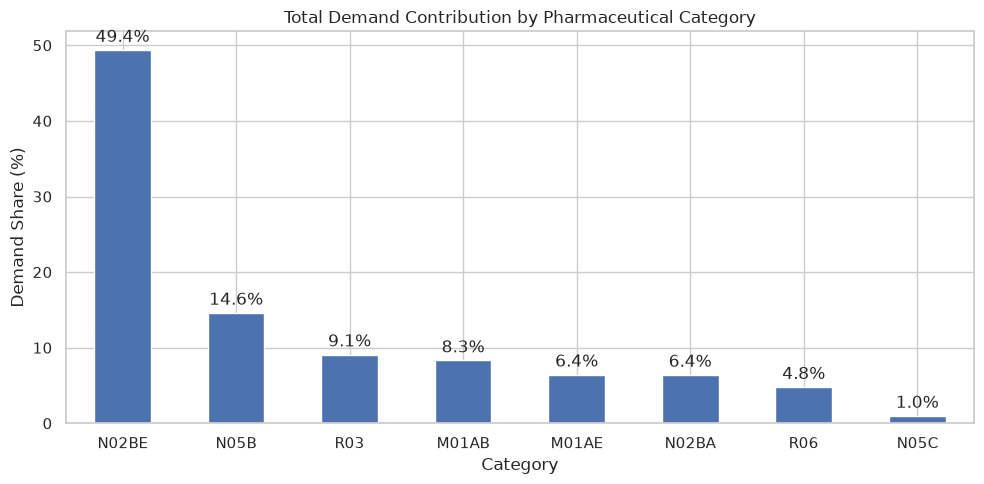

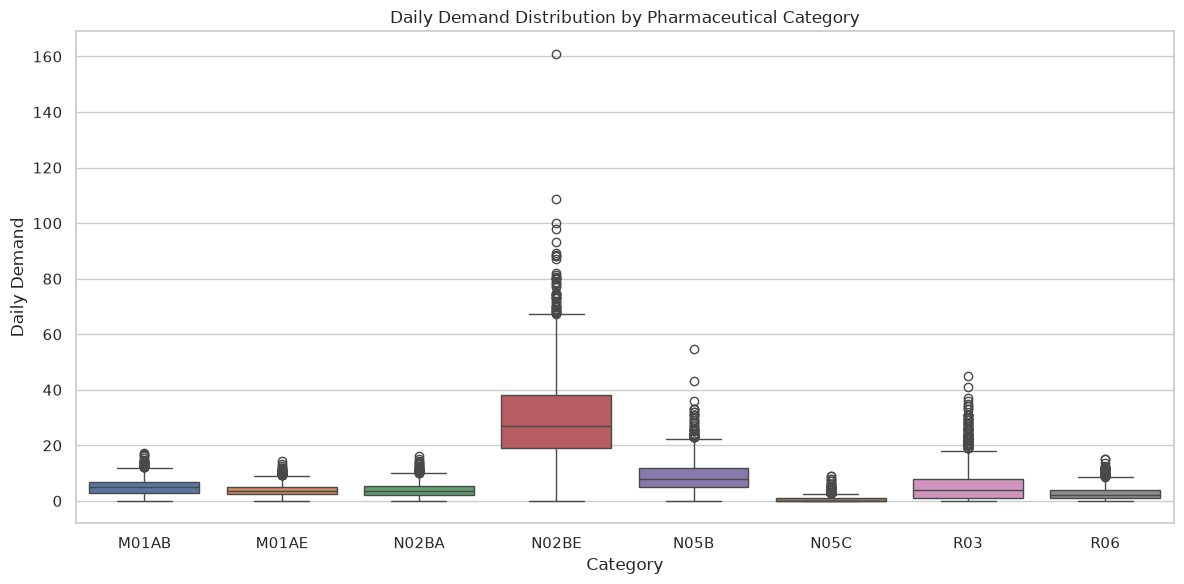

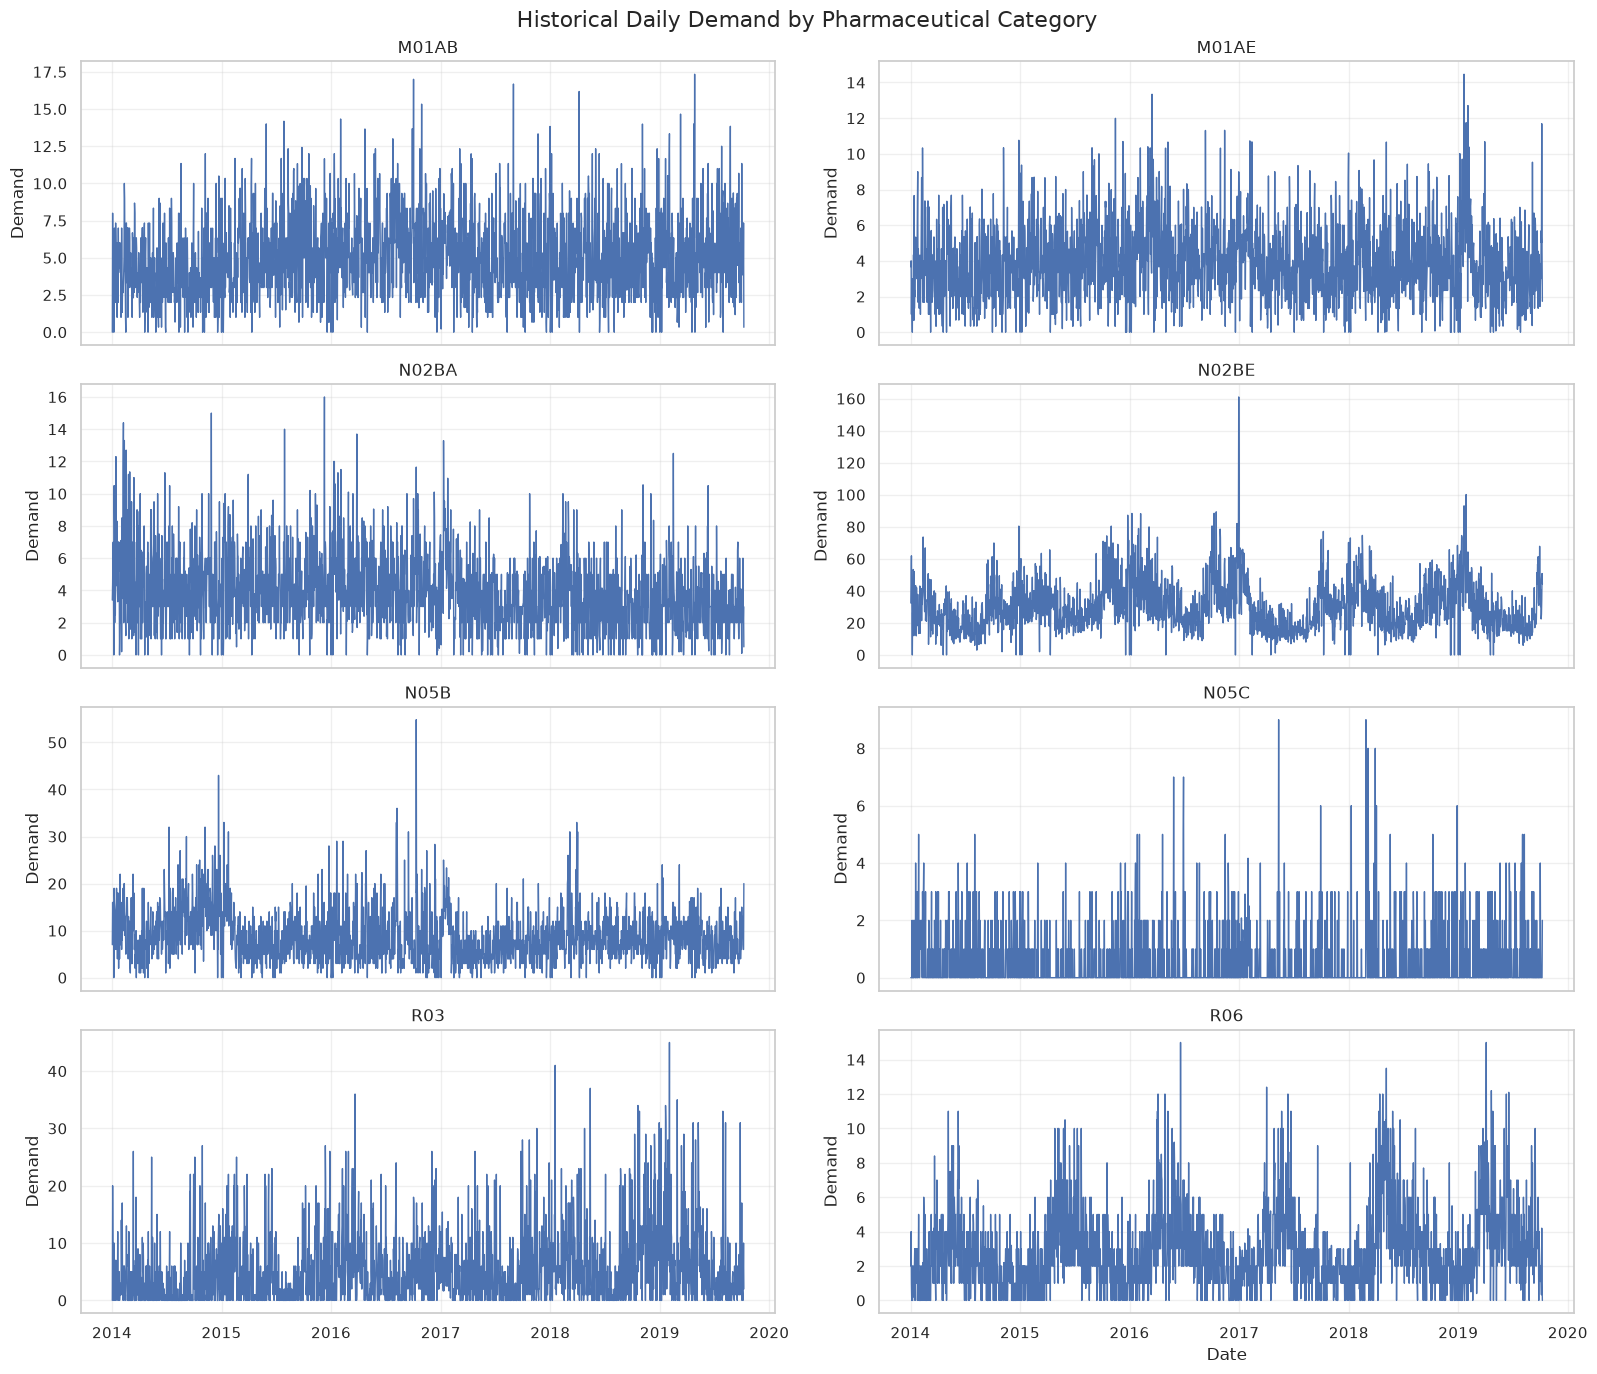

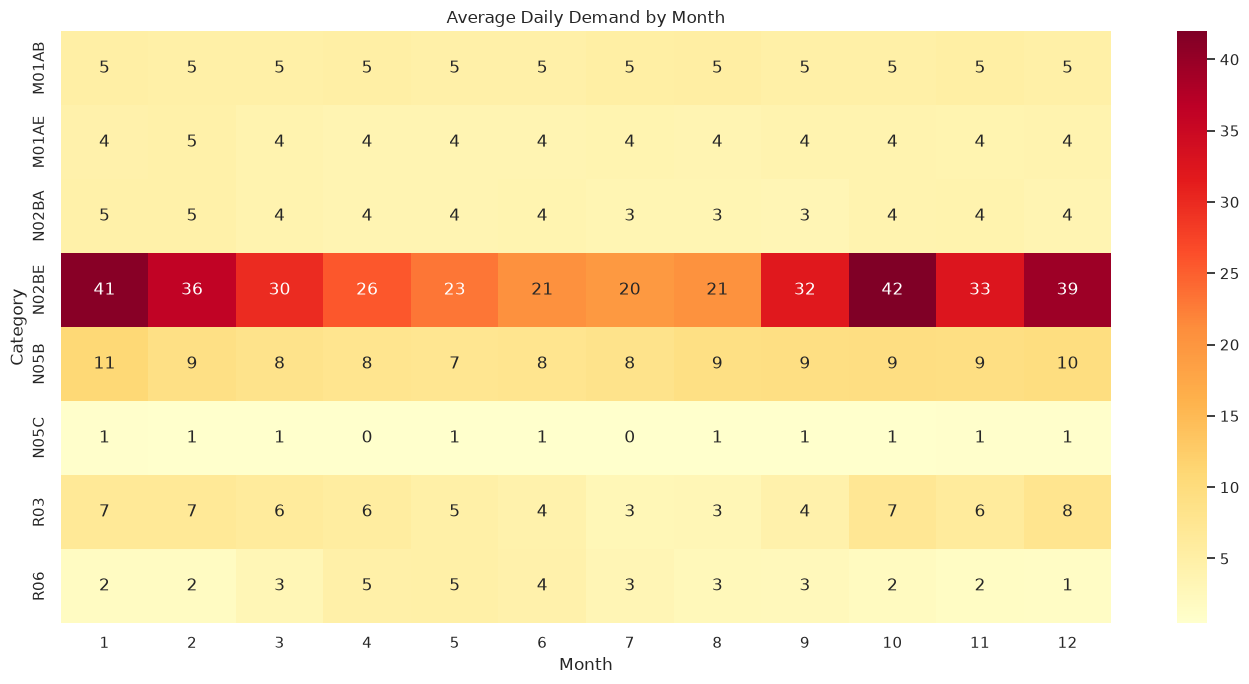

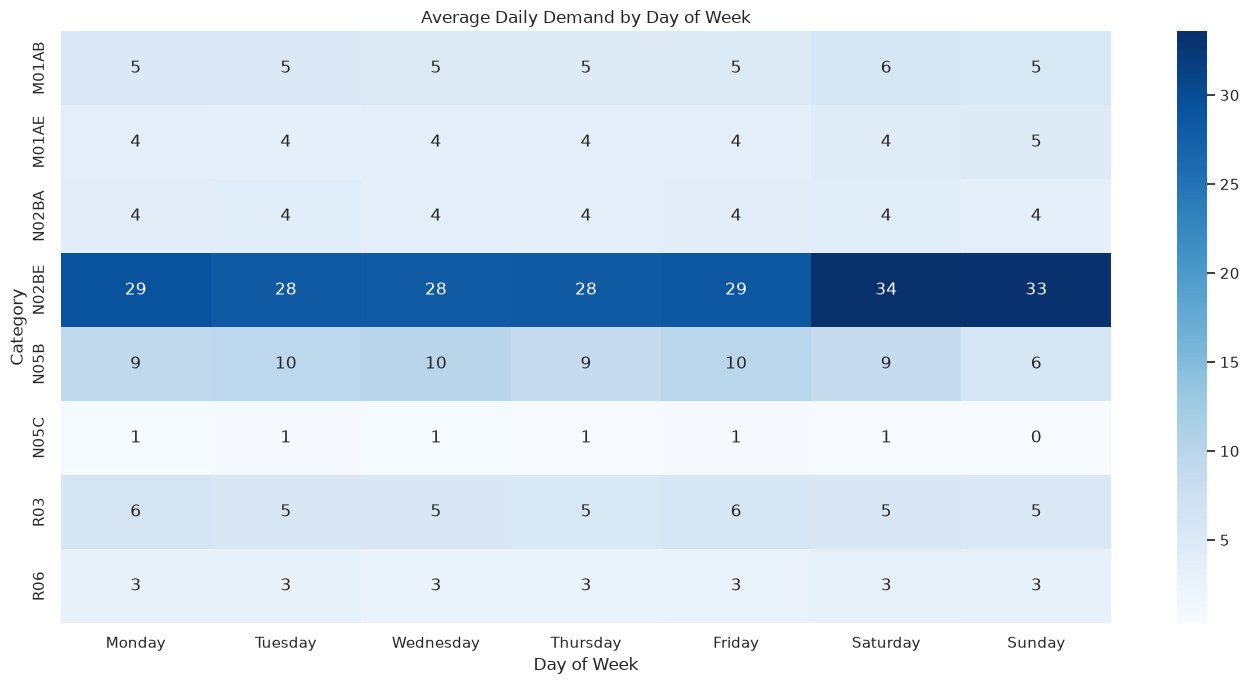

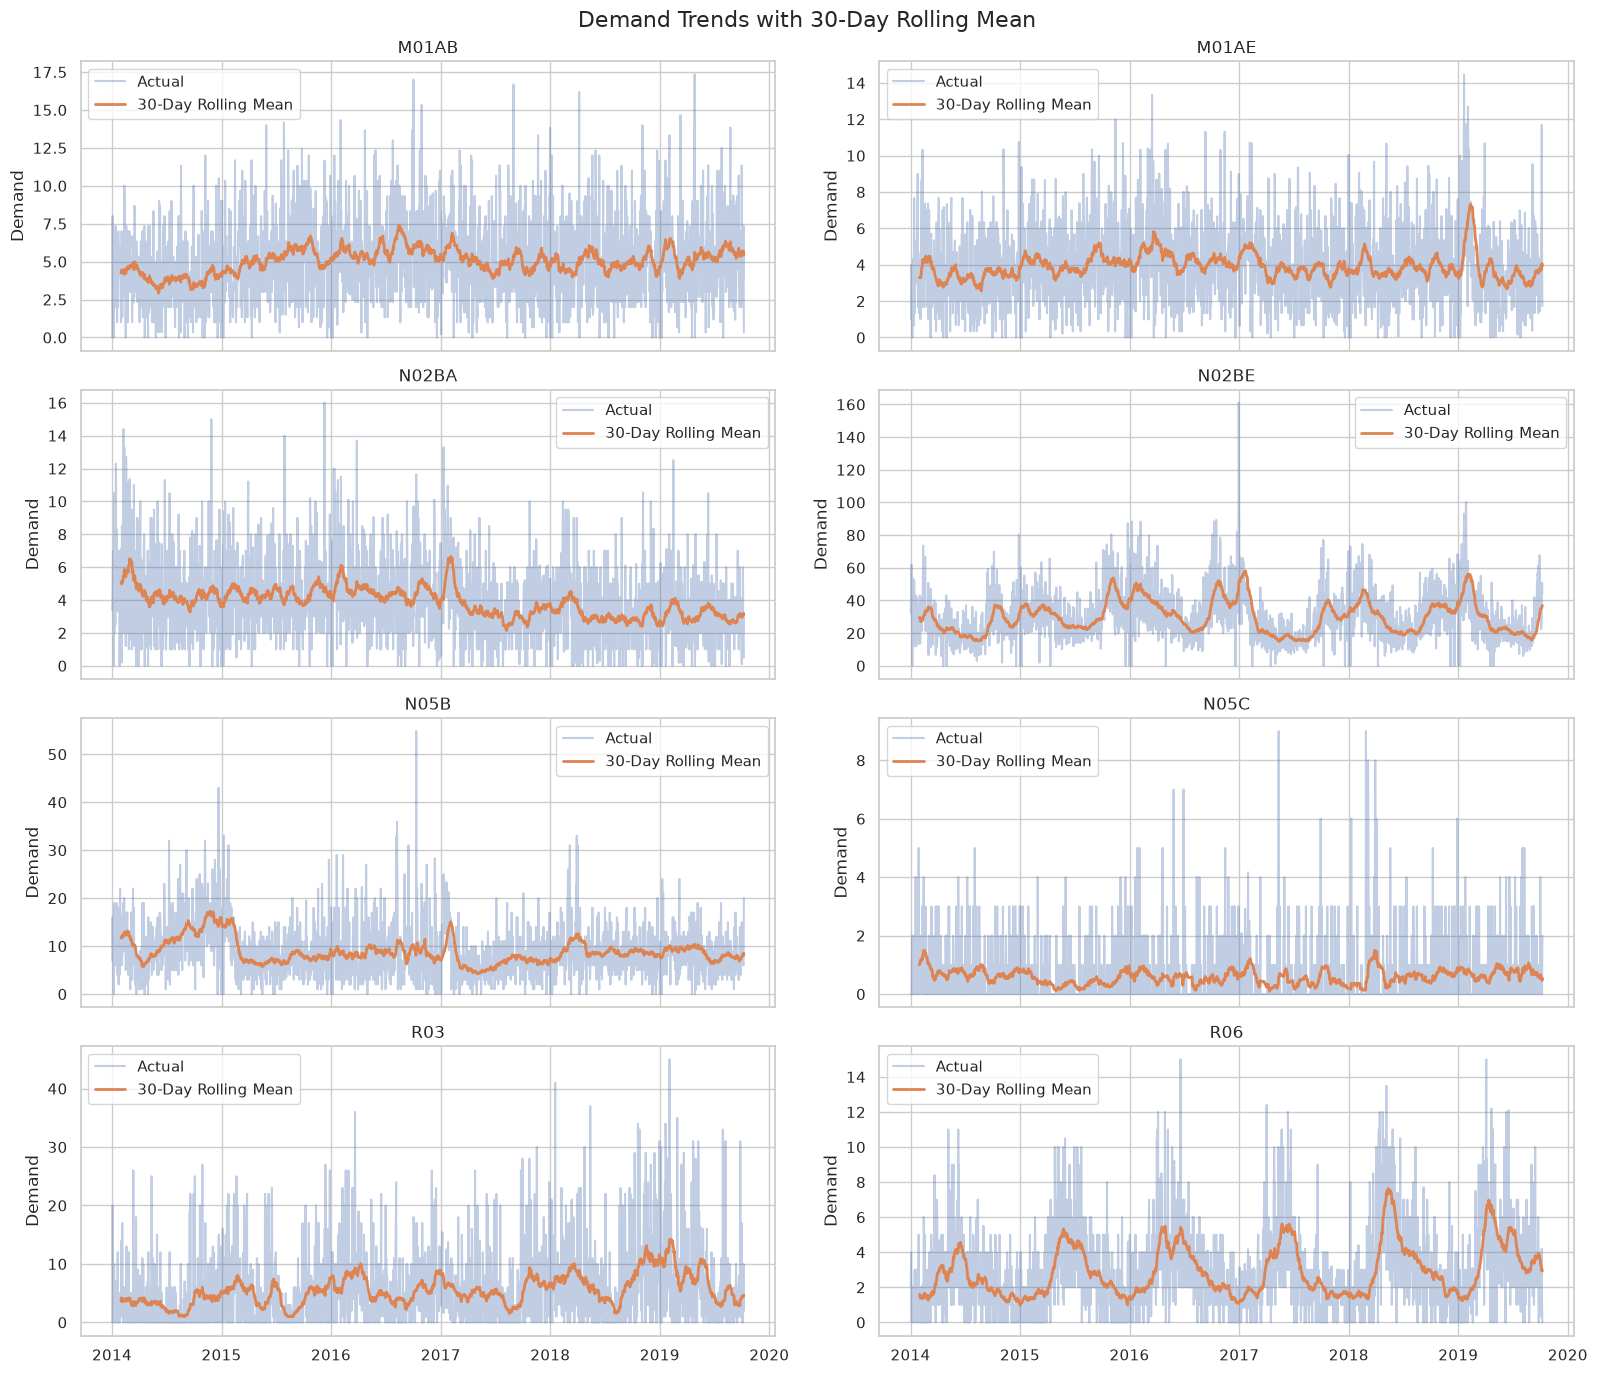

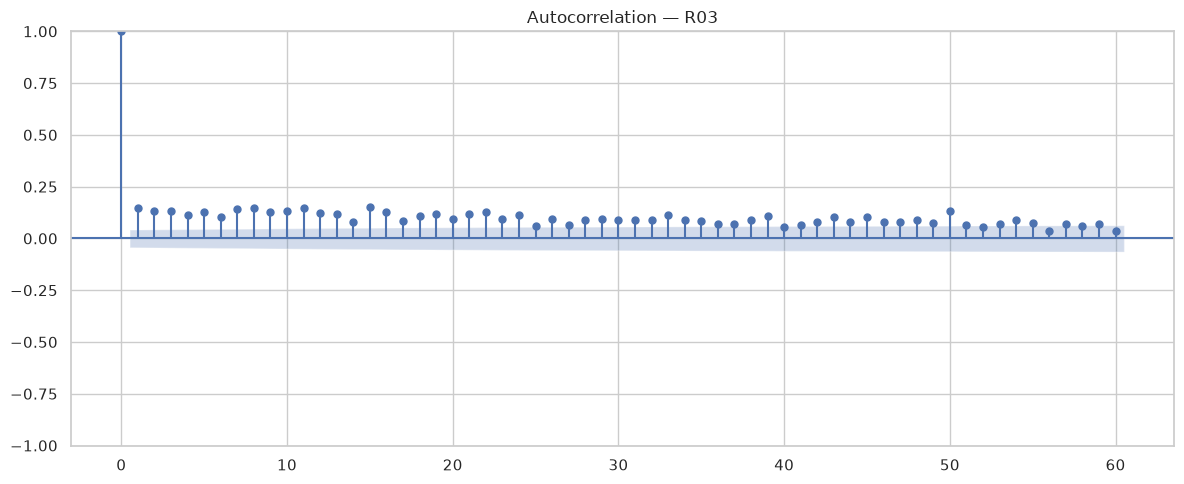

In [ ]:
from pathlib import Path
import sys
import warnings

# ------------------------------------------------------------------
# Project path
# ------------------------------------------------------------------

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# ------------------------------------------------------------------
# Scientific Python
# ------------------------------------------------------------------

import numpy as np
import pandas as pd


# ------------------------------------------------------------------
# Visualization
# ------------------------------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------------
# Statistical analysis
# ------------------------------------------------------------------

from statsmodels.graphics.tsaplots import plot_acf

# ------------------------------------------------------------------
# PharmaInsight AI modules
# ------------------------------------------------------------------

from ml.preprocessing.loader import load_dataset
from ml.analytics.descriptive import (
    calculate_descriptive_statistics,
)

# ------------------------------------------------------------------
# Configuration
# ------------------------------------------------------------------

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option(
    "display.float_format",
    lambda x: f"{x:,.3f}",
)

sns.set_theme(style="whitegrid")

print("PharmaInsight AI environment loaded successfully.")
print(f"Project root: {PROJECT_ROOT}")
print(f"Python: {sys.executable}")
daily = load_dataset("daily")

print(f"Rows:        {len(daily):,}")
print(f"Columns:     {len(daily.columns)}")
print(f"Start date:  {daily['datum'].min()}")
print(f"End date:    {daily['datum'].max()}")
daily.info()
daily.head()
TARGET_COLUMNS = [
    "M01AB",
    "M01AE",
    "N02BA",
    "N02BE",
    "N05B",
    "N05C",
    "R03",
    "R06",
]

print("Demand categories:")
for category in TARGET_COLUMNS:
    print(f"  - {category}")
missing_targets = [
    column
    for column in TARGET_COLUMNS
    if column not in daily.columns
]

if missing_targets:
    raise ValueError(
        f"Missing target columns: {missing_targets}"
    )

print("All target columns are present.")
descriptive_stats = calculate_descriptive_statistics(
    daily,
    target_columns=TARGET_COLUMNS,
)

descriptive_stats
variability = (
    descriptive_stats[
        [
            "category",
            "mean",
            "std",
            "coefficient_of_variation",
            "zero_demand_pct",
        ]
    ]
    .sort_values(
        "coefficient_of_variation",
        ascending=False,
    )
    .reset_index(drop=True)
)

variability
total_demand = (
    daily[TARGET_COLUMNS]
    .sum()
    .sort_values(ascending=False)
)

total_demand
category_share = (
    total_demand
    / total_demand.sum()
    * 100
).sort_values(ascending=False)

category_share
plt.figure(figsize=(10, 5))

ax = category_share.plot(
    kind="bar",
    figsize=(10, 5),
)

plt.title(
    "Total Demand Contribution by Pharmaceutical Category"
)

plt.xlabel("Category")
plt.ylabel("Demand Share (%)")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
    )

plt.tight_layout()
plt.show()
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=daily[TARGET_COLUMNS],
)

plt.title(
    "Daily Demand Distribution by Pharmaceutical Category"
)

plt.xlabel("Category")
plt.ylabel("Daily Demand")

plt.tight_layout()
plt.show()
fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(16, 14),
    sharex=True,
)

axes = axes.flatten()

for ax, category in zip(axes, TARGET_COLUMNS):
    ax.plot(
        daily["datum"],
        daily[category],
        linewidth=1,
    )

    ax.set_title(category)
    ax.set_ylabel("Demand")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Date")

fig.suptitle(
    "Historical Daily Demand by Pharmaceutical Category",
    fontsize=16,
)

plt.tight_layout()
plt.show()
daily_analysis = daily.copy()

daily_analysis["year"] = (
    daily_analysis["datum"].dt.year
)

daily_analysis["month"] = (
    daily_analysis["datum"].dt.month
)

daily_analysis["day_of_week"] = (
    daily_analysis["datum"].dt.day_name()
)

daily_analysis["day_of_year"] = (
    daily_analysis["datum"].dt.dayofyear
)

daily_analysis.head()
monthly_pattern = (
    daily_analysis
    .groupby("month")[TARGET_COLUMNS]
    .mean()
)

monthly_pattern
plt.figure(figsize=(14, 7))

sns.heatmap(
    monthly_pattern.T,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
)

plt.title(
    "Average Daily Demand by Month"
)

plt.xlabel("Month")
plt.ylabel("Category")

plt.tight_layout()
plt.show()
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

weekday_pattern = (
    daily_analysis
    .groupby("day_of_week")[TARGET_COLUMNS]
    .mean()
    .reindex(weekday_order)
)

weekday_pattern
plt.figure(figsize=(14, 7))

sns.heatmap(
    weekday_pattern.T,
    annot=True,
    fmt=".0f",
    cmap="Blues",
)

plt.title(
    "Average Daily Demand by Day of Week"
)

plt.xlabel("Day of Week")
plt.ylabel("Category")

plt.tight_layout()
plt.show()
rolling_30 = (
    daily_analysis[TARGET_COLUMNS]
    .rolling(window=30)
    .mean()
)

fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(16, 14),
    sharex=True,
)

axes = axes.flatten()

for ax, category in zip(axes, TARGET_COLUMNS):
    ax.plot(
        daily_analysis["datum"],
        daily_analysis[category],
        alpha=0.35,
        label="Actual",
    )

    ax.plot(
        daily_analysis["datum"],
        rolling_30[category],
        linewidth=2,
        label="30-Day Rolling Mean",
    )

    ax.set_title(category)
    ax.set_ylabel("Demand")
    ax.legend()

fig.suptitle(
    "Demand Trends with 30-Day Rolling Mean",
    fontsize=16,
)

plt.tight_layout()
plt.show()
category = "R03"

fig, ax = plt.subplots(
    figsize=(12, 5)
)

plot_acf(
    daily_analysis[category],
    lags=60,
    ax=ax,
)

ax.set_title(
    f"Autocorrelation — {category}"
)

plt.tight_layout()
plt.show()

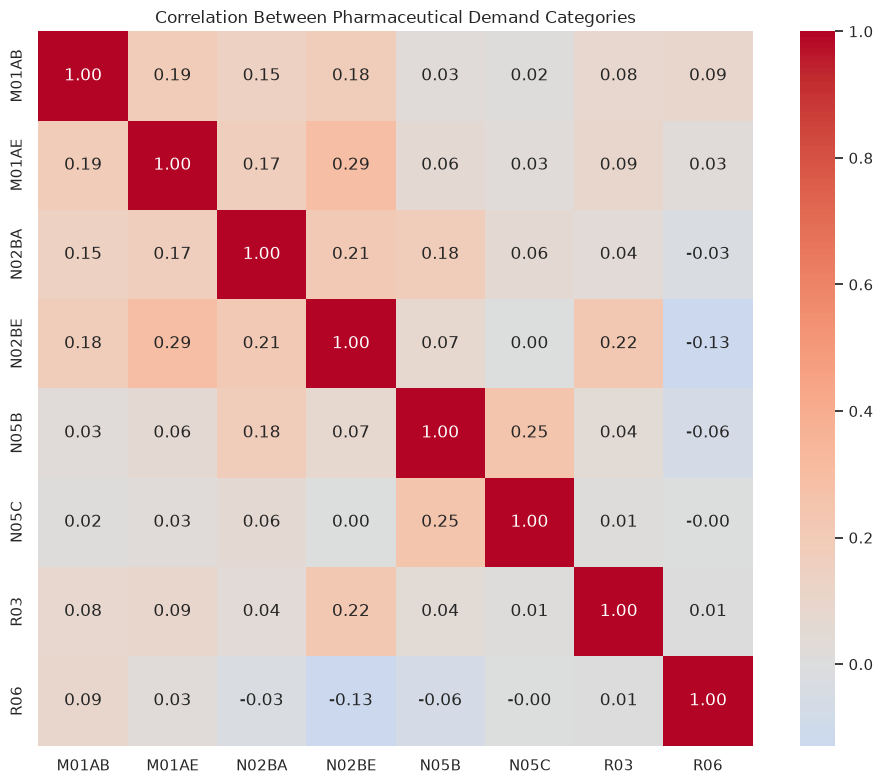

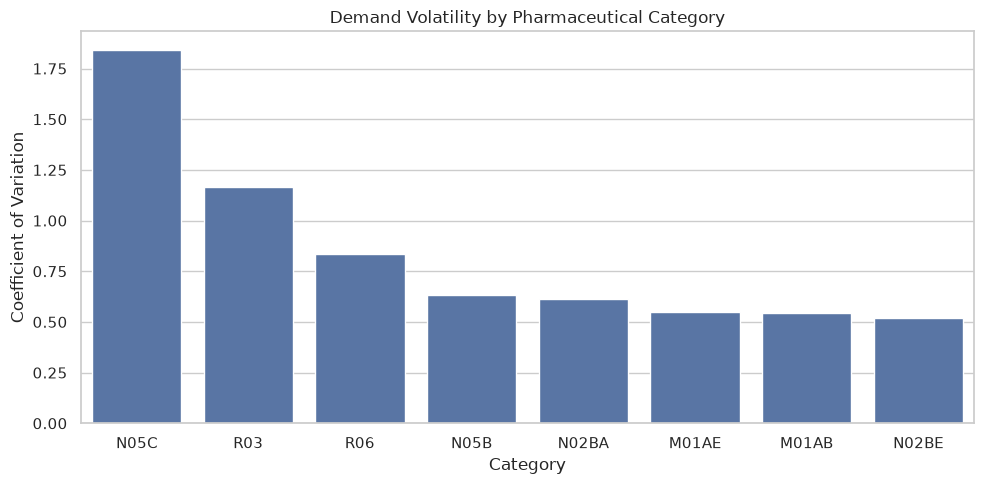

Saved forecastability profile to:
/workspaces/PharmaInsight-AI/reports/initial_forecastability_profile.csv


In [13]:
autocorrelation_results = []

for category in TARGET_COLUMNS:
    series = daily_analysis[category].dropna()

    autocorrelation_results.append(
        {
            "category": category,
            "lag_1": series.autocorr(lag=1),
            "lag_7": series.autocorr(lag=7),
            "lag_14": series.autocorr(lag=14),
            "lag_30": series.autocorr(lag=30),
            "lag_365": (
                series.autocorr(lag=365)
                if len(series) > 365
                else np.nan
            ),
        }
    )

autocorrelation_df = pd.DataFrame(
    autocorrelation_results
)

autocorrelation_df
correlation_matrix = (
    daily_analysis[TARGET_COLUMNS]
    .corr()
)

correlation_matrix
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
)

plt.title(
    "Correlation Between Pharmaceutical Demand Categories"
)

plt.tight_layout()
plt.show()
volatility = (
    descriptive_stats[
        [
            "category",
            "coefficient_of_variation",
        ]
    ]
    .sort_values(
        "coefficient_of_variation",
        ascending=False,
    )
)

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=volatility,
    x="category",
    y="coefficient_of_variation",
)

ax.set_title(
    "Demand Volatility by Pharmaceutical Category"
)

ax.set_xlabel("Category")
ax.set_ylabel("Coefficient of Variation")

plt.tight_layout()
plt.show()
forecastability_profile = descriptive_stats[
    [
        "category",
        "mean",
        "std",
        "coefficient_of_variation",
        "skewness",
        "kurtosis",
        "zero_demand_pct",
    ]
].copy()

forecastability_profile = (
    forecastability_profile
    .merge(
        autocorrelation_df,
        on="category",
        how="left",
    )
)

forecastability_profile
output_dir = PROJECT_ROOT / "reports"
output_dir.mkdir(
    parents=True,
    exist_ok=True,
)

forecastability_path = (
    output_dir
    / "initial_forecastability_profile.csv"
)

forecastability_profile.to_csv(
    forecastability_path,
    index=False,
)

print(
    f"Saved forecastability profile to:\n"
    f"{forecastability_path}"
)


## Initial Observations

The following questions should be answered from the analysis above:

1. Which pharmaceutical categories contribute the greatest total demand?
2. Which categories exhibit the highest demand variability?
3. Which categories show evidence of seasonal behavior?
4. Are there meaningful day-of-week effects?
5. Which categories exhibit strong autocorrelation?
6. Are pharmaceutical categories strongly correlated with one another?
7. Which categories appear easiest or hardest to forecast?
8. Are there obvious demand spikes or structural changes?

These observations will guide the selection of forecasting approaches in the next stage.

In [3]:
from pathlib import Path
import sys
import warnings

# Project root
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Scientific Python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from statsmodels.graphics.tsaplots import plot_acf

# PharmaInsight AI modules
from ml.preprocessing.loader import load_dataset
from ml.analytics.descriptive import calculate_descriptive_statistics
from ml.analytics.seasonality import build_forecastability_profile

# Configuration
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option(
    "display.float_format",
    lambda x: f"{x:,.3f}"
)

sns.set_theme(style="whitegrid")

print("PharmaInsight AI initialized.")
print(f"Project root: {PROJECT_ROOT}")
print(f"Python: {sys.executable}")
daily = load_dataset("daily")

TARGET_COLUMNS = [
    "M01AB",
    "M01AE",
    "N02BA",
    "N02BE",
    "N05B",
    "N05C",
    "R03",
    "R06",
]
forecastability_profile = build_forecastability_profile(
    dataframe=daily,
    target_columns=TARGET_COLUMNS,
    date_column="datum",
)

forecastability_profile
forecastability_summary = (
    forecastability_profile[
        [
            "category",
            "coefficient_of_variation",
            "zero_demand_pct",
            "lag_7",
            "trend_strength",
            "weekly_seasonality_strength",
            "annual_seasonality_strength",
            "demand_regime",
        ]
    ]
    .sort_values(
        "coefficient_of_variation",
        ascending=False,
    )
    .reset_index(drop=True)
)

forecastability_summary

PharmaInsight AI initialized.
Project root: /workspaces/PharmaInsight-AI
Python: /workspaces/PharmaInsight-AI/.venv/bin/python


,category,coefficient_of_variation,zero_demand_pct,lag_7,trend_strength,weekly_seasonality_strength,annual_seasonality_strength,demand_regime
0,N05C,1.842,67.901,0.063,0.002,0.048,0.109,Intermittent
1,R03,1.166,22.982,0.140,0.064,0.107,0.211,Intermittent
2,R06,0.833,12.156,0.332,0.044,0.137,0.431,Seasonal
3,N05B,0.633,2.042,0.233,0.092,0.225,0.298,Regular
4,N02BA,0.614,3.704,0.138,0.098,0.217,0.340,Seasonal
5,M01AE,0.548,1.709,0.116,0.024,0.214,0.350,Seasonal
6,M01AB,0.544,1.899,0.089,0.062,0.222,0.292,Regular
7,N02BE,0.521,1.235,0.473,0.076,0.232,0.452,Seasonal
